# Import required libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

# Permite visualização dos plots no notebook
%matplotlib inline

# Melhora a leitura de valores ponto flutuante
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
np.random.seed(1) # permitir a reprodução dos mesmos resultados

### **O que faz:**  
- Importa bibliotecas essenciais para manipulação de dados (`pandas`, `numpy`), visualização (`matplotlib`, `seaborn`) e modelagem (`sklearn`).  
- `%matplotlib inline` permite exibir gráficos diretamente no Jupyter Notebook.  
- Ajusta o `display.float_format` para exibir números de ponto flutuante de forma mais legível.  

# Carregamento dos Dados (disponível no GitHub)

Colunas:
Colunas:
- ida: notação para uma casa
- date: Data em que a casa foi vendida
- price: Preço é meta de previsão
- bedrooms: Número de quartos/casa
- bathrooms: Número de banheiros/casa
- sqft_living: metragem quadrada da casa
- sqft_lot: metragem quadrada do lote
- floors: Total de andares (níveis) na casa
- waterfront: Casa com vista para a orla
- view: Foi vista
- condition: Quão boa é a condição (geral)
- grade: nota geral dada à unidade habitacional, com base no sistema de classificação do Condado de King
- sqft_abovesquare: metragem da casa além do porão
- sqft_basement: metragem quadrada do porão
- yr_built: Ano de construção
- yr_renovated: Ano em que a casa foi reformada
- zipcode: zip
- lat: Coordenada de latitude
- long: Coordenada de longitude
- sqft_living15: Área da sala de estar em 2015(implica-- algumas renovações)
- sqft_lot15: área do tamanho do lote em 2015(implica-- algumas renovações)

In [ ]:
base = pd.read_csv('house_prices.csv')

# Análise Exploratória

In [ ]:
base.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [ ]:
base.shape

(21613, 21)

### **O que faz:**  
- Carrega o dataset `house_prices.csv` em um DataFrame `base`.  
- Exibe as primeiras linhas com `head()`.  
- Retorna a dimensão do dataset com `shape`.  

In [ ]:
print("Dataset Info:")
base.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float

### **O que faz:**  
- Exibe informações sobre colunas, tipos de dados e valores nulos.  

In [ ]:
print("\nBasic Statistics:")
print(base.describe().T)


Basic Statistics:
                 count          mean           std        min           25%  \
id            21613.00 4580301520.86 2876565571.31 1000102.00 2123049194.00   
price         21613.00     540088.14     367127.20   75000.00     321950.00   
bedrooms      21613.00          3.37          0.93       0.00          3.00   
bathrooms     21613.00          2.11          0.77       0.00          1.75   
sqft_living   21613.00       2079.90        918.44     290.00       1427.00   
sqft_lot      21613.00      15106.97      41420.51     520.00       5040.00   
floors        21613.00          1.49          0.54       1.00          1.00   
waterfront    21613.00          0.01          0.09       0.00          0.00   
view          21613.00          0.23          0.77       0.00          0.00   
condition     21613.00          3.41          0.65       1.00          3.00   
grade         21613.00          7.66          1.18       1.00          7.00   
sqft_above    21613.00       1788

### **O que faz:**  
- Exibe estatísticas como média, desvio padrão, valores mínimos e máximos.  
- `.T` (transposição) melhora a legibilidade.  

In [ ]:
print("\nMissing Values:")
print(base.isnull().sum())


Missing Values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


### **O que faz:**  
- Conta quantos valores ausentes existem em cada coluna.  

# Matriz de Correlação entre variáveis numéricas

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='bedrooms', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='sqft_living', ylabel='price'>,
        <Axes: xlabel='sqft_lot', ylabel='price'>,
        <Axes: xlabel='floors', ylabel='price'>,
        <Axes: xlabel='grade', ylabel='price'>,
        <Axes: xlabel='sqft_above', ylabel='price'>,
        <Axes: xlabel='sqft_basement', ylabel='price'>,
        <Axes: xlabel='yr_built', ylabel='price'>,
        <Axes: xlabel='yr_renovated', ylabel='price'>,
        <Axes: xlabel='sqft_living15', ylabel='price'>,
        <Axes: xlabel='sqft_lot15', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='bedrooms'>,
        <Axes: xlabel='bedrooms', ylabel='bedrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bedrooms'>,
        <Axes: xlabel='sqft_living', ylabel='bedrooms'>,
        <Axes: xlabel='sqft_lot', ylabel='bedrooms'>,
        <Axes: xlabel='floors', ylabel='bedrooms'>,

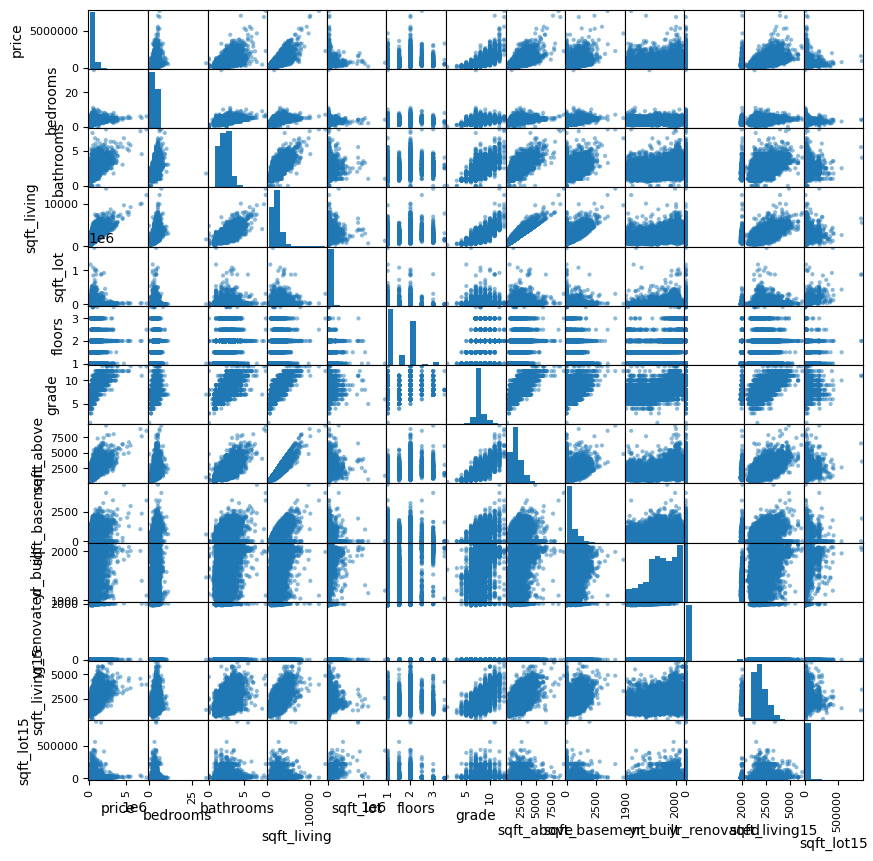

In [ ]:
pd.plotting.scatter_matrix(base[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','grade','sqft_above','sqft_basement','yr_built','yr_renovated','sqft_living15','sqft_lot15']], figsize=(10,10))

### **O que faz:**  
- Gera uma matriz de dispersão para visualizar relações entre variáveis numéricas.  

### **Sugestão de melhoria:**  
- O gráfico pode ficar sobrecarregado. Filtrar variáveis mais relevantes pode ajudar.  

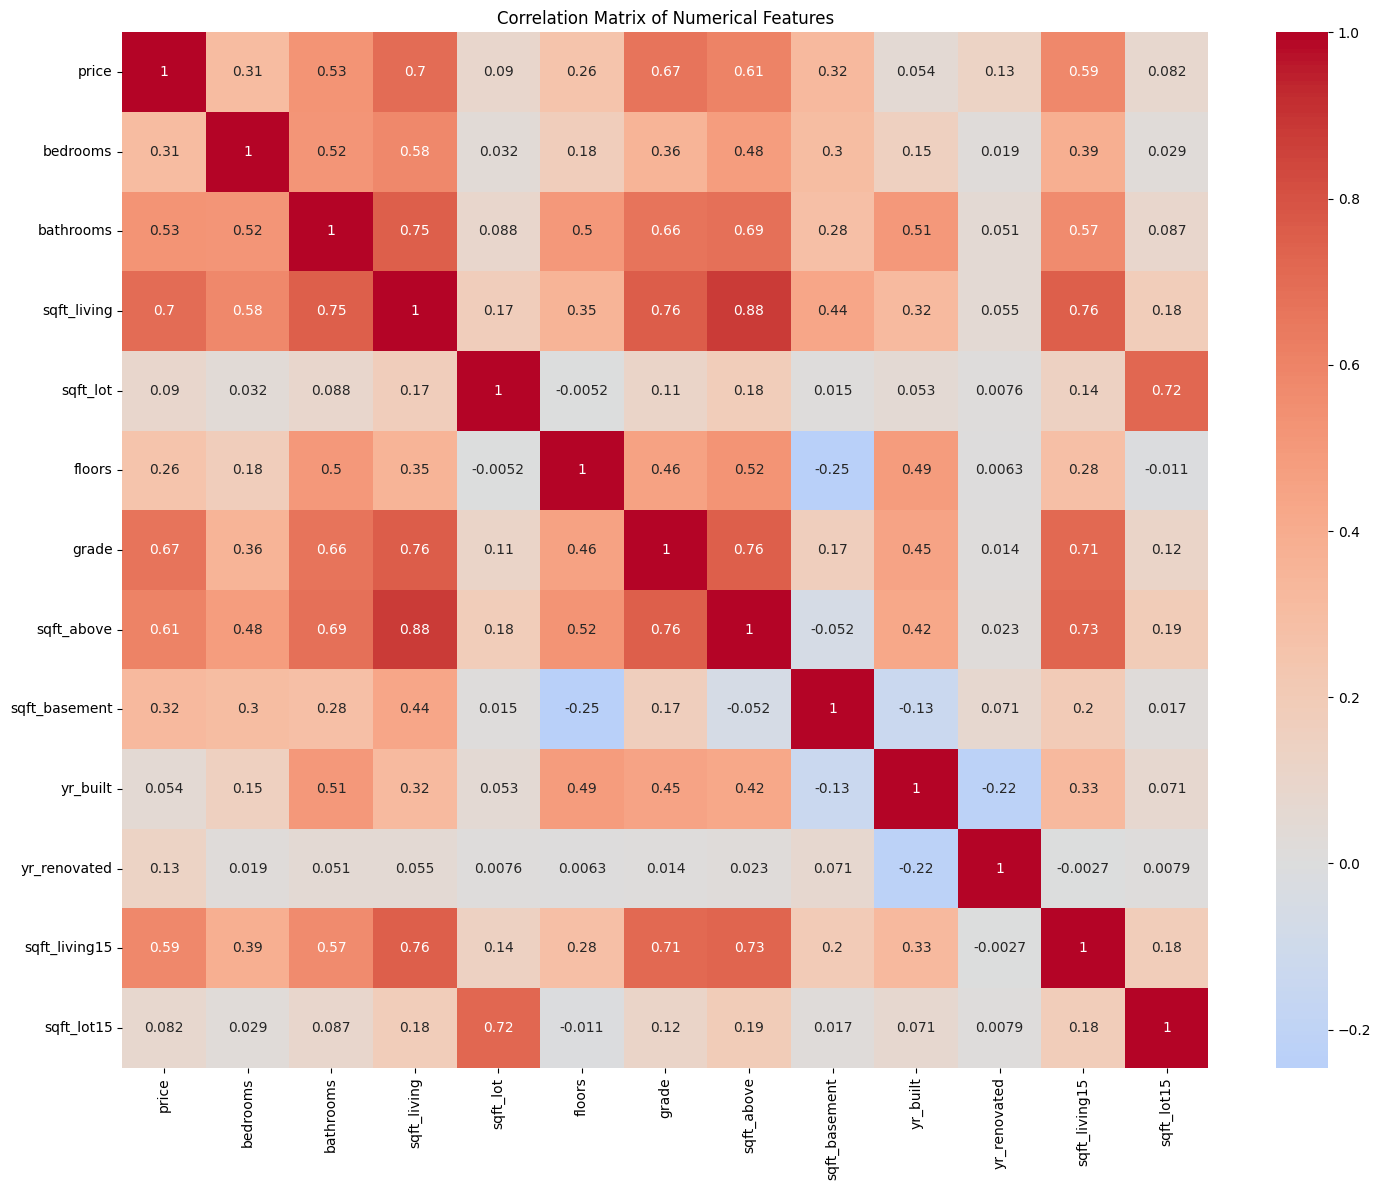

In [ ]:
plt.figure(figsize=(15, 12))
correlation_matrix = base[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','grade','sqft_above','sqft_basement','yr_built','yr_renovated','sqft_living15','sqft_lot15']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### **O que faz:**  
- Calcula e exibe a matriz de correlação entre variáveis numéricas.  
- Usa `seaborn` para visualizar melhor os dados.  

# Distribuição dos Preços

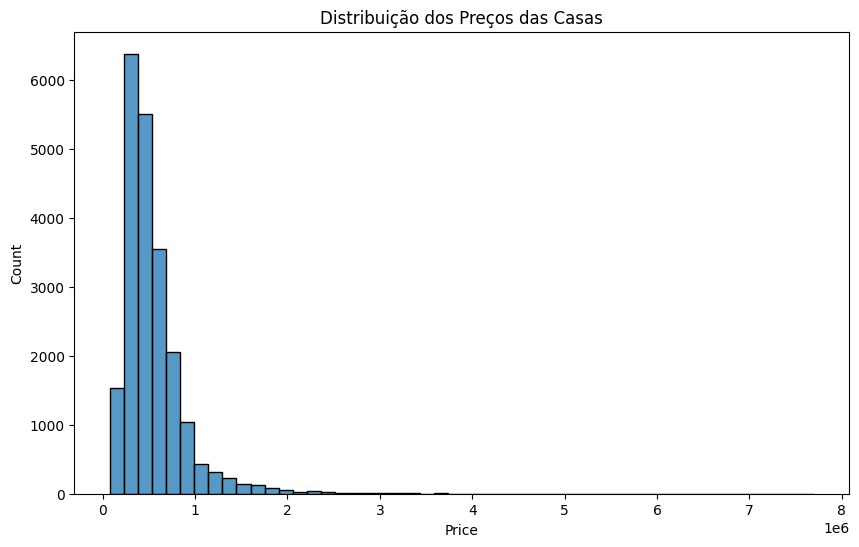

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(base['price'], bins=50)
plt.title('Distribuição dos Preços das Casas')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

### **O que faz:**  
- Plota um histograma para visualizar a distribuição de preços.  

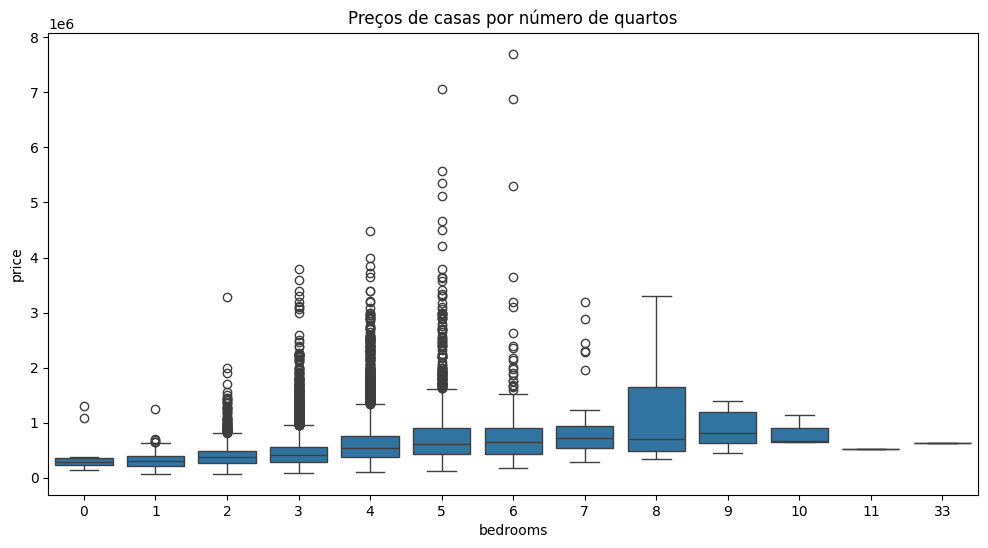

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='bedrooms', y='price', data=base)
plt.title('Preços de casas por número de quartos')
plt.show()

### **O que faz:**  
- Mostra como o preço varia conforme o número de quartos.  

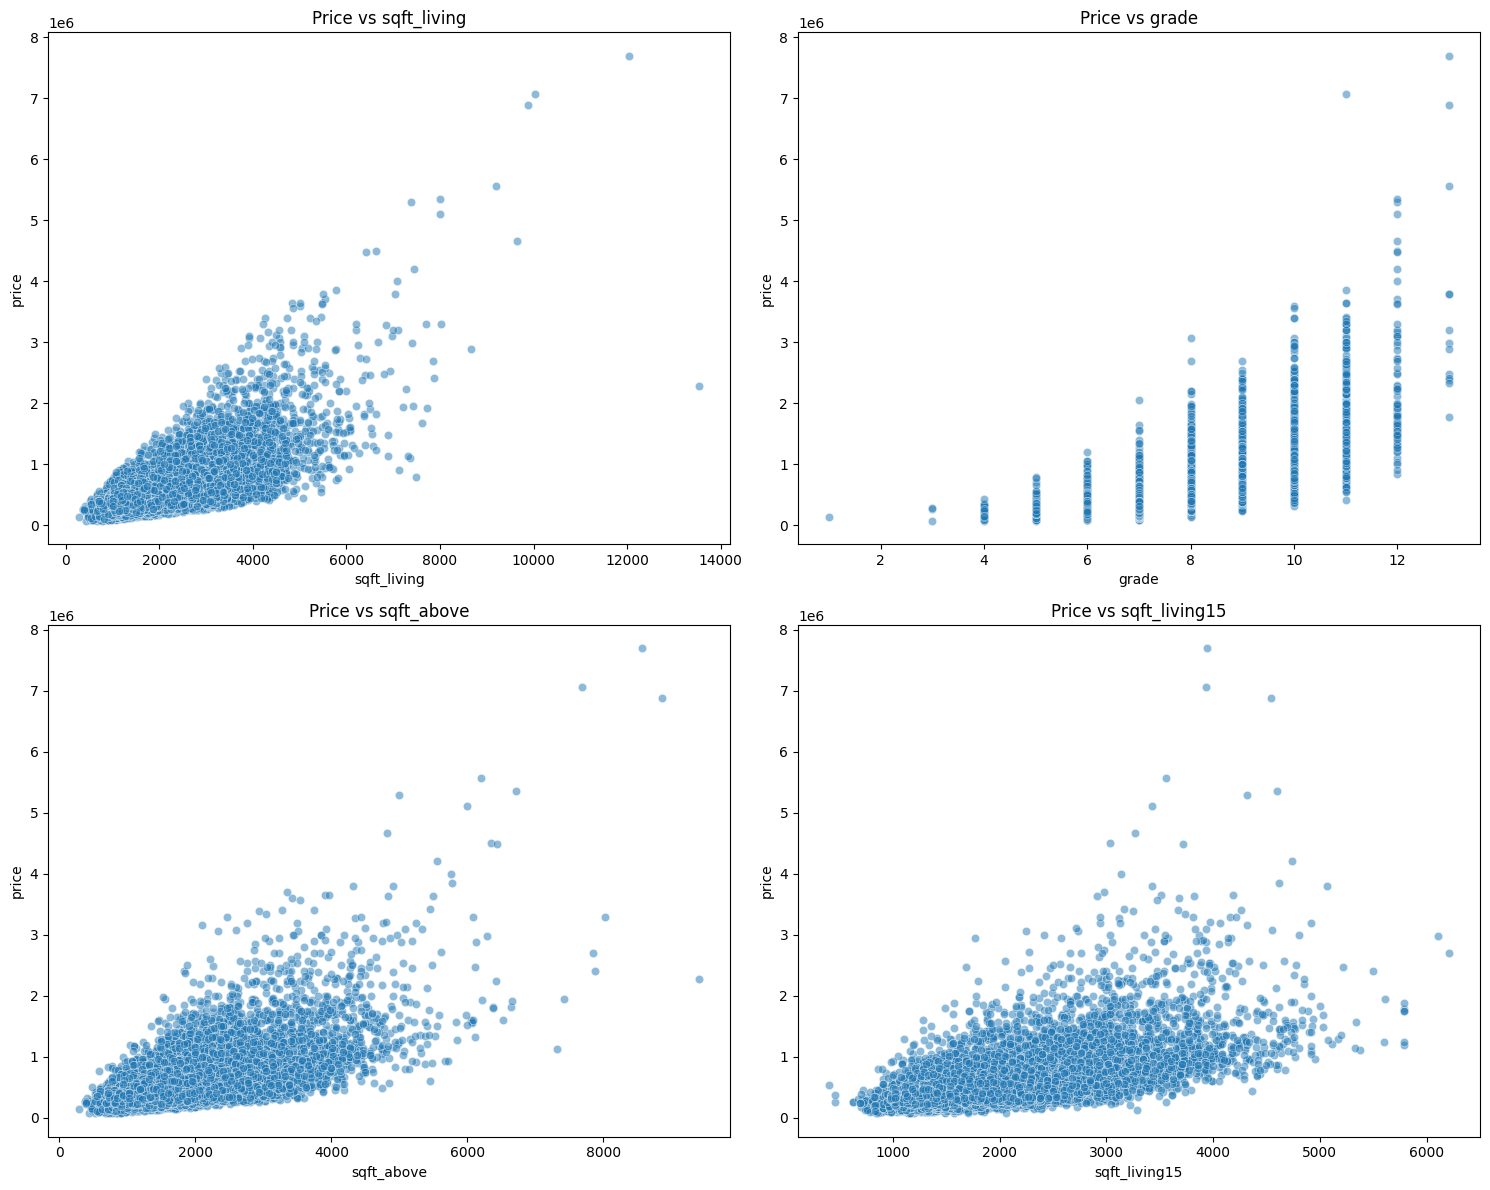

In [ ]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    sns.scatterplot(data=base, x=feature, y='price', ax=axes[row, col], alpha=0.5)
    axes[row, col].set_title(f'Price vs {feature}')
plt.tight_layout()
plt.show()

### **O que faz:**  
- Cria 4 scatter plots para variáveis importantes.  

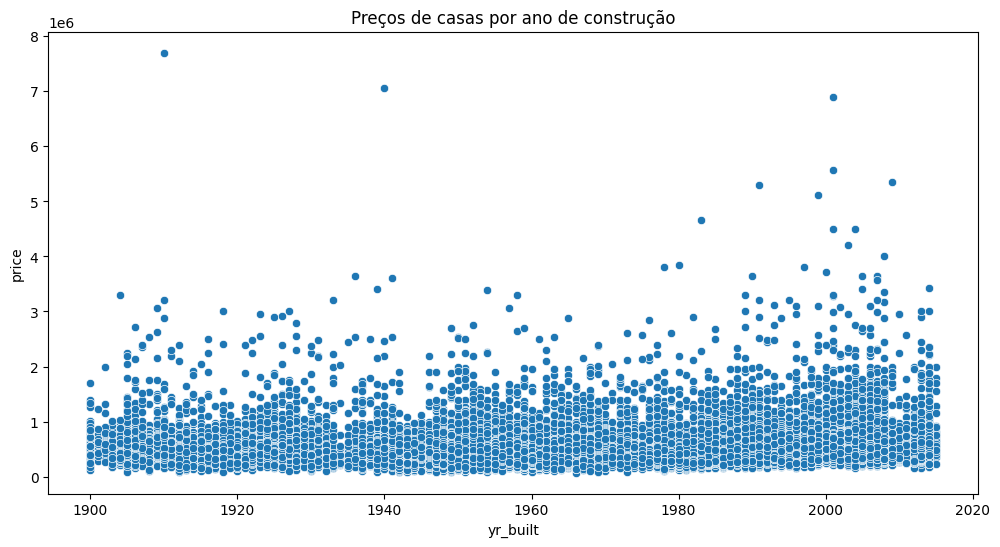

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=base, x='yr_built', y='price')
plt.title('Preços de casas por ano de construção')
plt.show()

# Split dos dados em conjuntos de treino (70%) e teste (30%)

In [ ]:
X = base[['sqft_living']]
y = base['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### **O que faz:**  
- Separa os dados em treino (70%) e teste (30%).  

# Criação e treinamento - Modelo Regressão Linear Simples (predição do preço baseado no tamanho)

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

### **O que faz:**  
- Treina um modelo de Regressão Linear.  

In [ ]:
print("\nModel Summary:")
print(f"Coefficient (slope): {regressor.coef_[0]:.2f}")
print(f"Intercept: {regressor.intercept_:.2f}")
print(f"R² Score (training): {regressor.score(X_train, y_train):.4f}")


Model Summary:
Coefficient (slope): 273.81
Intercept: -31356.78
R² Score (training): 0.4868


### **O que faz:**  
- Exibe os coeficientes e o R² do modelo.  

# Predição nos dados de treino

In [ ]:
predictions_train = regressor.predict(X_train)

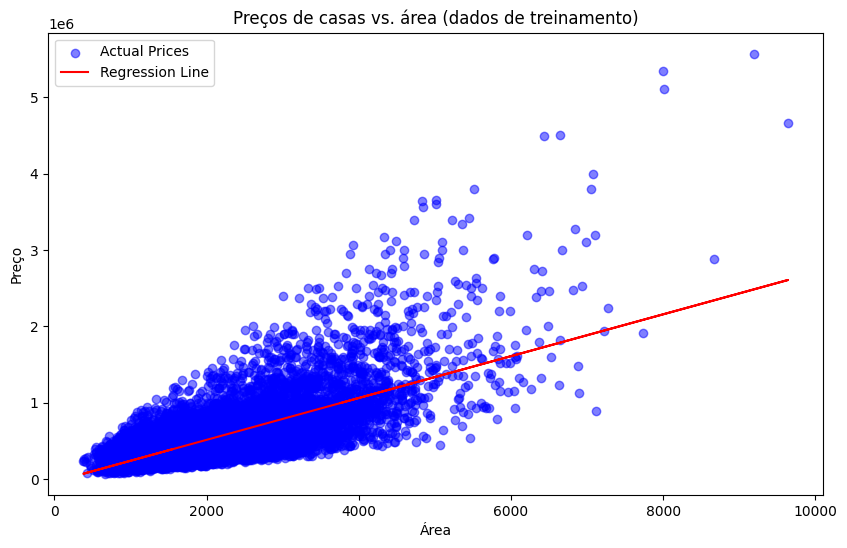

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Actual Prices')
plt.plot(X_train, predictions_train, color='red', label='Regression Line')
plt.xlabel('Área')
plt.ylabel('Preço')
plt.title('Preços de casas vs. área (dados de treinamento)')
plt.legend()
plt.show()

### **O que faz:**  
- Plota os preços reais e a linha de regressão.  

# Predição nos dados de teste

In [ ]:
predictions_test = regressor.predict(X_test)

# Erro médio absoluto

In [ ]:
mae = mean_absolute_error(y_test, predictions_test)
print(f"\nMean Absolute Error: ${mae:,.2f}")


Mean Absolute Error: $175,221.70


# R² para o conjunto de teste

In [ ]:
r2 = r2_score(y_test, predictions_test)
print(f"R² Score (test): {r2:.4f}")

R² Score (test): 0.5031


### **O que faz:**  
- Calcula erro médio absoluto (MAE) e R².  

### **Interpretação:**

**Coefficient (slope): 273.81**

O coeficiente angular (inclinação) indica o quanto a variável dependente (y) muda quando a variável independente (X) aumenta em 1 unidade.

Valor: 273.81  
Interpretação:
Para cada aumento de 1 unidade em X, o valor previsto de y aumenta, em média, 273,81 unidades.

**R² Score (training): 0.4868**

O R² (coeficiente de determinação) mede quanto da variação dos dados é explicada pelo modelo.

Seu valor varia entre 0 e 1:  
R² = 1 → o modelo explica 100% da variação.  
R² = 0 → o modelo não explica a variação melhor do que usar a média.

Isso significa que o modelo explica aproximadamente 48,68% da variação da variável alvo.  

Em outras palavras:

Cerca de 48,7% das mudanças em y são explicadas pela variável X.
Os 51,3% restantes são devidos a outros fatores ou ao erro do modelo.

---
**Interpretação conjunta das métricas**

Com os resultados temos:

Coeficiente (slope): 273,81  
Intercepto: -31.356,78  
R² (treinamento): 0,4868  
R² (teste): 0,5031  
MAE: $175.221,70  

Podemos concluir que:

Existe uma relação linear positiva entre a variável independente e o preço.
O modelo explica cerca de 50% da variação dos preços, o que representa um desempenho moderado.  
O fato de o R² de teste ser muito próximo ao de treinamento indica que o modelo está estável e consegue fazer previsões semelhantes em dados não vistos.  
Entretanto, o MAE de aproximadamente $175 mil mostra que as previsões ainda apresentam um erro médio considerável, sugerindo que uma única variável não é suficiente para prever os preços com alta precisão.

Conclusão: o modelo é consistente e generaliza bem, mas seu poder preditivo é moderado. Para aumentar a precisão, seria interessante incluir mais variáveis relevantes (como localização, área do imóvel, número de quartos, idade do imóvel, entre outras), utilizando uma regressão linear múltipla ou outros modelos de aprendizado de máquina.


### **O Que Significa o Valor $ R^2 $?**  
O coeficiente de determinação $R^2 $ mede a proporção da variabilidade da variável resposta $ y $ que é explicada pelo modelo de regressão.


$$R^2 = 1 - \frac{\sum (y_{\text{real}} - y_{\text{previsto}})^2}{\sum (y_{\text{real}} - \bar{y})^2}$$

Onde:  
- $ \sum (y_{\text{real}} - y_{\text{previsto}})^2 $ é a soma dos erros ao quadrado (SSE - **Sum of Squared Errors**).  
- $ \sum (y_{\text{real}} - \bar{y})^2 $ é a soma total da variabilidade dos dados (TSS - **Total Sum of Squares**).  

**Interpretação do $ R^2 $:**  
- $ R^2 = 1 $ → O modelo explica **100%** da variação dos dados (perfeito, mas pode indicar overfitting).  
- $ R^2 = 0 $ → O modelo **não explica nada** da variabilidade dos dados.  
- $ R^2 $ próximo de **1** → Melhor ajuste, mas precisa ser analisado junto aos resíduos.  
- **$ R^2 $ negativo** → O modelo é pior do que uma média simples.  

**Atenção:**  
- Um $ R^2 $ alto **não garante** um bom modelo, pois pode haver overfitting.  
- O $ R^2 $ não detecta erros sistemáticos (como não linearidade).  
- Para comparar modelos com diferentes números de variáveis, utilize o **$ R^2 $ ajustado**.


$$ R^2_{\text{ajustado}} = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - p - 1} \right)$$

Onde $ n $ é o número de observações e $ p $ o número de variáveis independentes.  


# Análise de Resíduos

### **Análise Gráfica dos Resíduos do Modelo**  
A análise dos resíduos é essencial para avaliar se os pressupostos da regressão linear foram atendidos.  

#### **1. O que são resíduos?**  
Os resíduos são as diferenças entre os valores observados $( y_{\text{real}} $) e os valores preditos pelo modelo ($ y_{\text{previsto}} $):  

$$\text{Resíduo} = y_{\text{real}} - y_{\text{previsto}}$$

Se o modelo for adequado, os resíduos devem apresentar um comportamento aleatório, sem padrões evidentes.



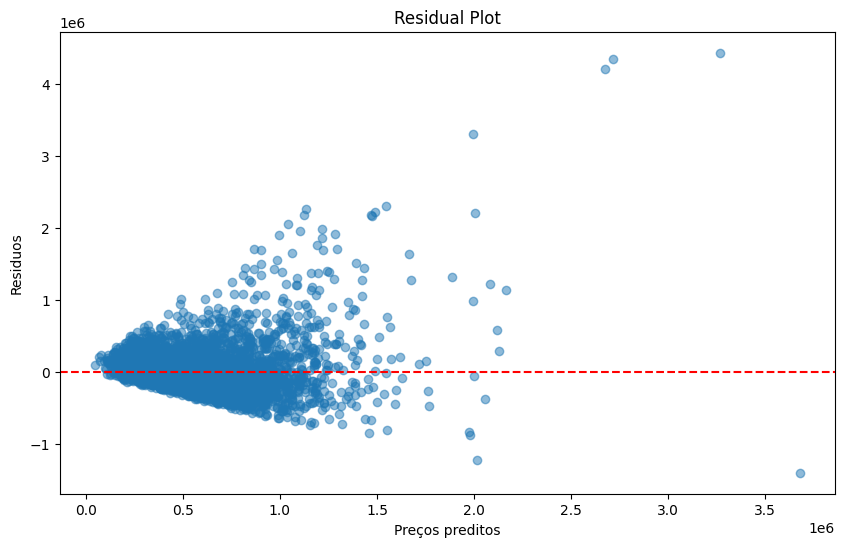

In [ ]:
residuals = y_test - predictions_test

plt.figure(figsize=(10, 6))
plt.scatter(predictions_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Preços preditos')
plt.ylabel('Residuos')
plt.title('Residual Plot')
plt.show()

**Interpretação:**  
- **Boa regressão:** Resíduos distribuídos aleatoriamente ao redor de zero.  
- **Tendências ou curvaturas:** Indicam que o modelo não está capturando toda a estrutura dos dados (talvez uma relação não linear).  
- **Aumento da variabilidade dos resíduos (cone):** Indica heterocedasticidade (violação do pressuposto de variância constante).  


### **O que faz:**  
- Avalia a distribuição dos erros do modelo.  

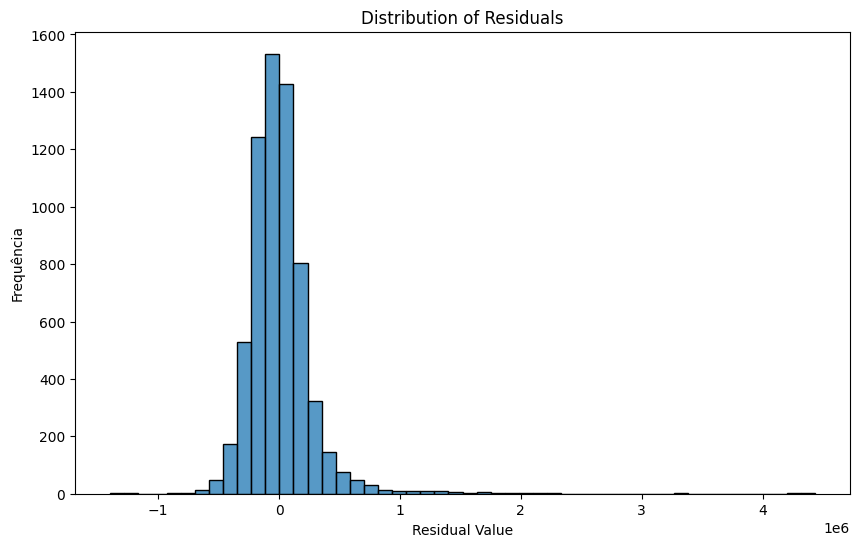

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequência')
plt.show()

**Interpretação:**  
- **Distribuição aproximadamente normal:** Modelo adequado.  
- **Assimetria ou picos atípicos:** Indica que os resíduos não são normalmente distribuídos, o que pode afetar inferências estatísticas.  

# Regressão Linear Múltipla

# Pré-processamento de dados - remoção de colunas desnecessárias

In [ ]:
columns_to_drop = ['id', 'date', 'sqft_living15', 'sqft_lot15', 'sqft_basement']
base_mlr = base.drop(columns=columns_to_drop)

**O que faz?**  
- Remove colunas que podem não ser úteis para a previsão, como `id` (identificador único), `date` (data da venda) e algumas outras.  

**Sugestões de melhoria:**  
- Antes de remover colunas, pode ser interessante verificar se `sqft_basement` realmente não contribui para o modelo. Se `sqft_basement` for relevante, podemos incluí-lo novamente.  
- Caso `date` seja importante, pode-se convertê-lo para uma métrica útil, como o ano da venda.  

# Split dados, conjuntos de características e alvo

In [ ]:
X_mlr = base_mlr.drop('price', axis=1)
y_mlr = base_mlr['price']

**O que faz?**  
- `X_mlr` contém todas as variáveis preditoras.  
- `y_mlr` é o preço das casas (variável dependente).  

# Dividir os dados em conjuntos de treinamento (70%) e de teste (30%)

In [ ]:
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y_mlr, test_size=0.3, random_state=1
)

**O que faz?**  
- Divide os dados em **70% treino** e **30% teste**.  
- Define `random_state=1` para garantir reprodutibilidade.  

**Sugestões de melhoria:**  
- Testar diferentes proporções (80/20 ou 60/40) pode ser útil dependendo do tamanho do dataset.  

# Crie e treine o modelo de regressão linear múltipla

In [ ]:
regressor_mlr = LinearRegression()
regressor_mlr.fit(X_train_mlr, y_train_mlr)

LinearRegression()

**O que faz?**  
- Cria um modelo de **Regressão Linear Múltipla** e o treina com os dados de treinamento.  

**Sugestões de melhoria:**  
- **Verificar multicolinearidade**: Antes do treinamento, pode-se calcular o **VIF (Variance Inflation Factor)** para verificar se há colunas altamente correlacionadas.  
- Se houver multicolinearidade, podemos remover algumas variáveis correlacionadas.  

In [ ]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train_mlr, regressor_mlr.predict(X_train_mlr))

print("\nModel Summary:")
print("\nFeature Coefficients:")
for feature, coef in zip(X_mlr.columns, regressor_mlr.coef_):
    print(f"{feature}: {coef:,.2f}")
print(f"\nIntercept: {regressor_mlr.intercept_:,.2f}")
print(f"R² Score (training): {r2_train:.4f}")


Model Summary:

Feature Coefficients:
bedrooms: -32,104.62
bathrooms: 37,388.21
sqft_living: 147.29
sqft_lot: -0.05
floors: 7,876.53
waterfront: 560,389.35
view: 53,287.53
condition: 26,099.50
grade: 98,807.66
sqft_above: 36.20
yr_built: -2,558.32
yr_renovated: 20.76
zipcode: -570.85
lat: 618,451.55
long: -199,507.40

Intercept: 6,556,113.22
R² Score (training): 0.7032


**O que faz?**  
- Exibe os coeficientes de cada variável no modelo.  
- Mostra o intercepto e o **\( R^2 \)** do conjunto de treino.  

**Sugestões de melhoria:**  
- Normalizar ou padronizar os dados antes da regressão pode melhorar a interpretação dos coeficientes.  
- Usar o **\( R^2 \) ajustado**, pois o \( R^2 \) pode aumentar artificialmente à medida que adicionamos mais variáveis.  

# Faça predições no conjunto de teste

In [ ]:
predictions_mlr = regressor_mlr.predict(X_test_mlr)

**O que faz?**  
- Usa o modelo treinado para prever os preços das casas no conjunto de teste.  

# Cálculo das métricas

In [ ]:
mae_mlr = mean_absolute_error(y_test_mlr, predictions_mlr)
r2_test = r2_score(y_test_mlr, predictions_mlr)

print(f"\nTest Set Metrics:")
print(f"Mean Absolute Error: ${mae_mlr:,.2f}")
print(f"R² Score (test): {r2_test:.4f}")



Test Set Metrics:
Mean Absolute Error: $128,974.65
R² Score (test): 0.6893


**O que faz?**  
- Calcula o **erro absoluto médio (MAE)** e o **$R^2$** no conjunto de teste.  

**Sugestões de melhoria:**  
- Incluir outras métricas, como **RMSE (Root Mean Squared Error)**, para medir a dispersão dos erros.  

# Análise das Features

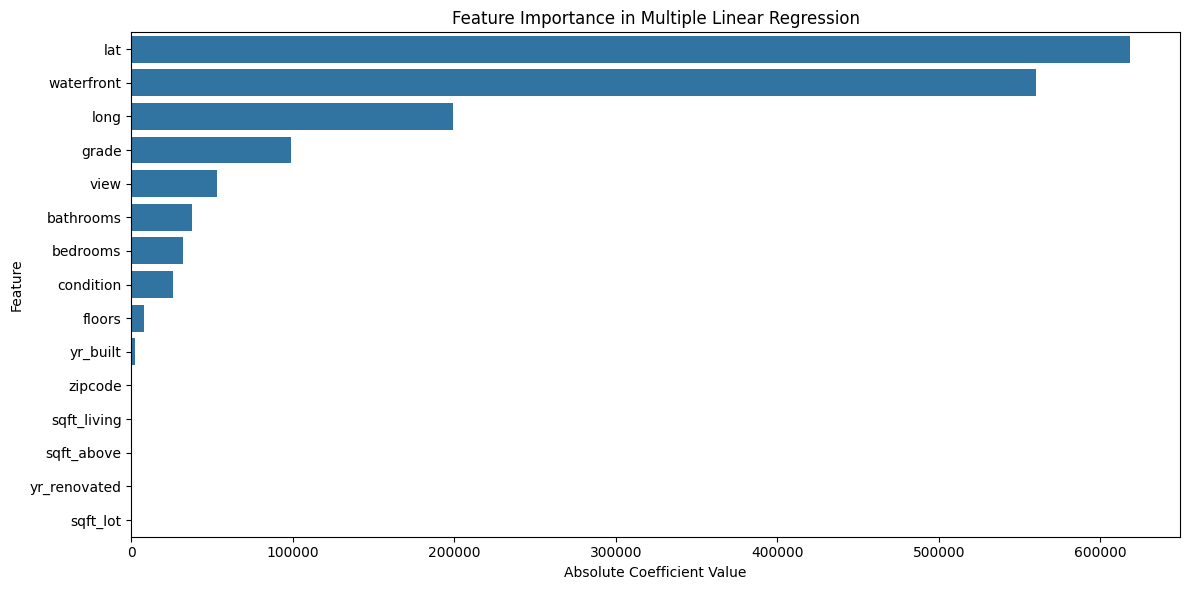

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_mlr.columns,
    'Absolute Coefficient': np.abs(regressor_mlr.coef_)
})
feature_importance = feature_importance.sort_values('Absolute Coefficient', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='Absolute Coefficient', y='Feature')
plt.title('Feature Importance in Multiple Linear Regression')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

**O que faz?**  
- Exibe um gráfico mostrando as variáveis mais influentes no modelo.  

**Sugestões de melhoria:**  
- Os coeficientes podem ser enganosos se as variáveis tiverem escalas diferentes. Normalizar os dados antes pode tornar a análise mais justa.  

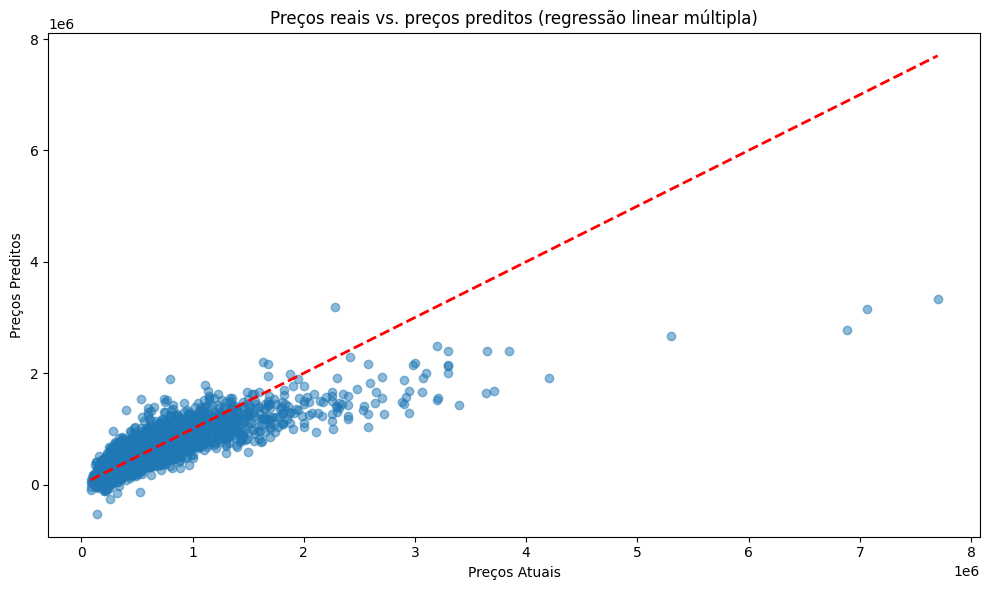

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_mlr, predictions_mlr, alpha=0.5)
plt.plot([y_test_mlr.min(), y_test_mlr.max()], [y_test_mlr.min(), y_test_mlr.max()],
         'r--', lw=2)
plt.xlabel('Preços Atuais')
plt.ylabel('Preços Preditos')
plt.title('Preços reais vs. preços preditos (regressão linear múltipla)')
plt.tight_layout()
plt.show()

**O que faz?**  
- Compara os preços reais e os preditos.  

Se os pontos estiverem próximos da linha vermelha, o modelo está performando bem.  

# Análise Residual para Regressão Linear Múltipla

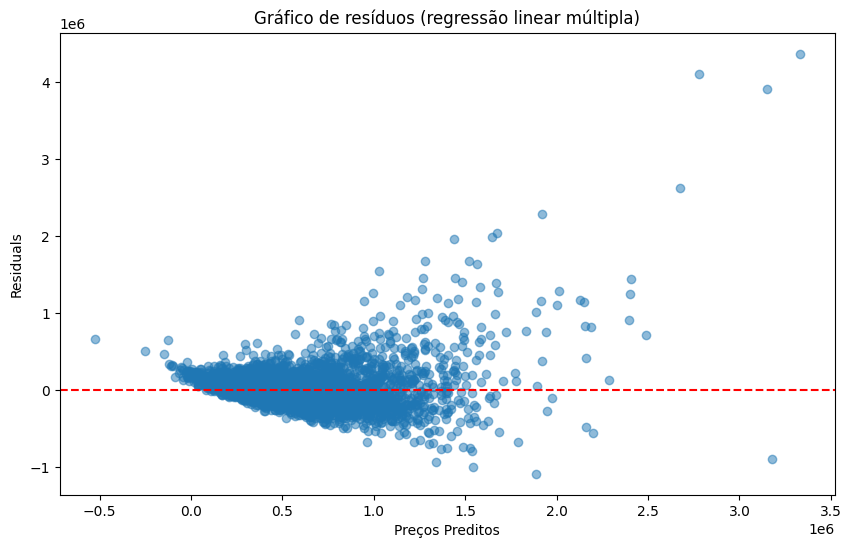

In [ ]:
residuals_mlr = y_test_mlr - predictions_mlr

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions_mlr, residuals_mlr, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Preços Preditos')
plt.ylabel('Residuals')
plt.title('Gráfico de resíduos (regressão linear múltipla)')
plt.show()


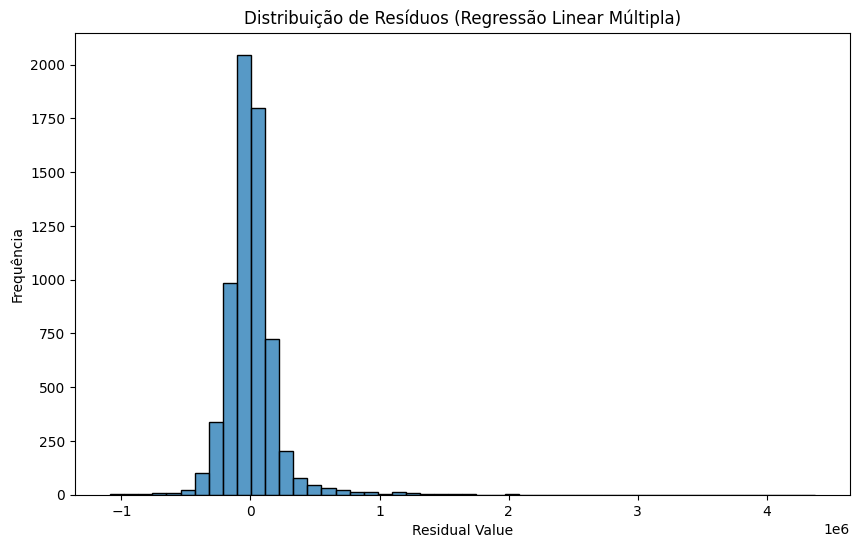

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals_mlr, bins=50)
plt.title('Distribuição de Resíduos (Regressão Linear Múltipla)')
plt.xlabel('Residual Value')
plt.ylabel('Frequência')
plt.show()

Ambos ajudam a avaliar se os resíduos são aleatórios (bom modelo) ou se há padrões (problema de especificação).  

**Sugestão:**  
- Verificar **homocedasticidade** (se a dispersão dos resíduos é constante).  

# Comparação entre as métricas de desempenho entre regressão linear simples e múltipla

In [ ]:
print("\n" + "="*50)
print("Model Comparison")
print("="*50)
print("\nSimple Linear Regression:")
print(f"R² Score (test): {r2:.4f}")
print(f"Mean Absolute Error: ${mae:,.2f}")
print("\nMultiple Linear Regression:")
print(f"R² Score (test): {r2_test:.4f}")
print(f"Mean Absolute Error: ${mae_mlr:,.2f}")

# Additional insights
print("\nAdditional Insights:")
improvement_r2 = ((r2_test - r2) / r2) * 100
improvement_mae = ((mae - mae_mlr) / mae) * 100
print(f"R² Melhoria: {improvement_r2:.1f}%")
print(f"MAE Melhoria: {improvement_mae:.1f}%")

# Top 5 most influential features
print("\nTop 5 Features mais Influenciáveis:")
print(feature_importance.head().to_string(index=False))


Model Comparison

Simple Linear Regression:
R² Score (test): 0.5031
Mean Absolute Error: $175,221.70

Multiple Linear Regression:
R² Score (test): 0.6893
Mean Absolute Error: $128,974.65

Additional Insights:
R² Melhoria: 37.0%
MAE Melhoria: 26.4%

Top 5 Features mais Influenciáveis:
   Feature  Absolute Coefficient
       lat             618451.55
waterfront             560389.35
      long             199507.40
     grade              98807.66
      view              53287.53


**O que faz?**  
- Compara os resultados da regressão linear simples com a múltipla.  

**Sugestões:**  
- Avaliar se a adição de variáveis realmente melhora a generalização do modelo.  
- Se o \( R^2 \) melhorou pouco, talvez o modelo linear não seja adequado, e modelos mais complexos (como regressão polinomial ou árvores de decisão) podem ser considerados.  